<a href="https://colab.research.google.com/github/sujitx-vs/Deep-Neural-Networks---PGCP_AI/blob/main/Time_Series_LSTM_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

IN LSTM OR RNN IN TIME SERIES DATA FIRST THING TO DO IS SCALING.|

In [ ]:
df = pd.read_csv('/content/DailyDelhiClimateTrain.csv')

In [ ]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [ ]:
temp = df[['meantemp']]
temp.head()

,meantemp
0,10.000000
1,7.400000
2,7.166667
3,8.666667
4,6.000000


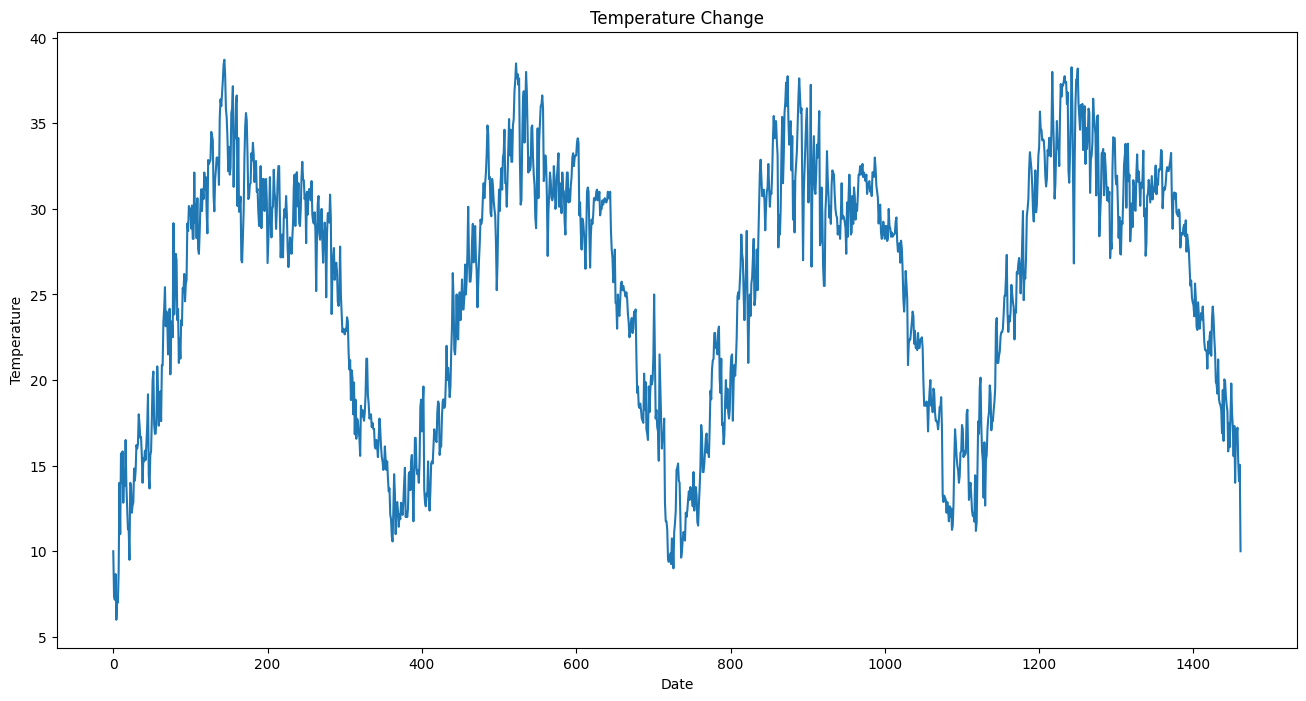

In [ ]:
plt.figure(figsize=(16,8))
plt.title('Temperature Change')
plt.plot(temp)
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.show()

In [ ]:
print(temp.shape)

(1462, 1)


In [ ]:
print(temp.isnull().sum())

meantemp    0
dtype: int64


In [ ]:
from statsmodels.tsa.stattools import acf

In [ ]:
acf_val = acf(temp)

In [ ]:
print(acf_val)

[1.         0.9711027  0.95095435 0.93435913 0.92457295 0.91551781
 0.90737097 0.89843343 0.89046222 0.88351839 0.87855285 0.87618765
 0.87108249 0.86575916 0.85981725 0.85384141 0.84625367 0.83890942
 0.83112316 0.82443026 0.8159426  0.80555558 0.79472453 0.78396174
 0.77645828 0.76750406 0.75910245 0.74987832 0.74150154 0.7333316
 0.72481656 0.71526761]


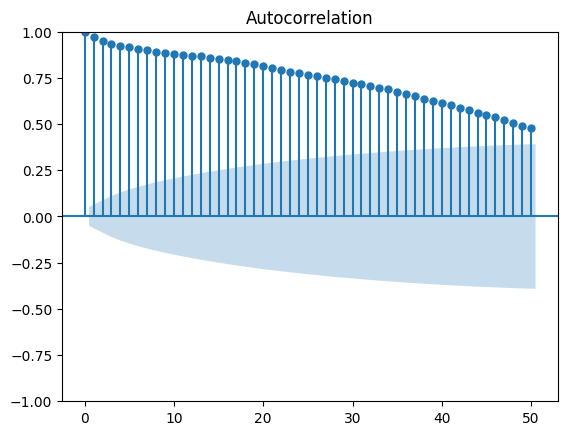

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(temp,lags=50)
plt.show()

In [ ]:
# scaler = MinMaxScaler()
# temp_scaled = scaler.fit_transform(temp) # this may introduce data leakage. so scaling should be done after spliting.

In [ ]:
split_index = int(len(temp)*0.8)

train_data = temp[:split_index]
test_data = temp[split_index:]

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [ ]:
train_scaled

array([[0.12227074],
       [0.04279476],
       [0.0356623 ],
       ...,
       [0.56741266],
       [0.55786026],
       [0.50054585]])

In [ ]:
test_scaled

array([[0.55225619],
       [0.54830786],
       [0.62090611],
       [0.61708515],
       [0.63537118],
       [0.64599709],
       [0.63045852],
       [0.58269651],
       [0.61746725],
       [0.67656477],
       [0.72980349],
       [0.5705968 ],
       [0.61899563],
       [0.60931587],
       [0.64574236],
       [0.72052402],
       [0.73362445],
       [0.7510917 ],
       [0.80431223],
       [0.83487991],
       [0.81959607],
       [0.80431223],
       [0.77565502],
       [0.73158661],
       [0.71120815],
       [0.75604076],
       [0.80240175],
       [0.72751092],
       [0.73973799],
       [0.7871179 ],
       [0.82914847],
       [0.84443231],
       [0.90747817],
       [0.87627365],
       [0.875     ],
       [0.8558952 ],
       [0.85780568],
       [0.8558952 ],
       [0.83296943],
       [0.79221252],
       [0.77374454],
       [0.7871179 ],
       [0.83870087],
       [0.82914847],
       [0.86059792],
       [0.8580786 ],
       [0.82723799],
       [0.876

In [ ]:
look_back = 30
X_train=[]
y_train=[]
for i in range(len(train_scaled)-look_back):
  X_train.append(train_scaled[i:(i+look_back)])
  y_train.append(train_scaled[i+look_back])
X_train=np.array(X_train)
y_train=np.array(y_train)

In [ ]:
look_back = 30
X_test=[]
y_test=[]
for i in range(len(test_scaled)-look_back):
  X_test.append(test_scaled[i:(i+look_back)])
  y_test.append(test_scaled[i+look_back])
X_test=np.array(X_test)
y_test=np.array(y_test)

In [ ]:
# split = int(len(X)*0.8)
# X_train = X[:split]
# X_test = X[split:]

# y_train = y[:split]
# y_test = y[split:]

In [ ]:
print(X_train.shape)
X_test.shape

(1139, 30, 1)


(263, 30, 1)

In [ ]:
# # Split another method.
# from sklearn.model_selection import train_test_split
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=False)

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(look_back, 1)),
    keras.layers.LSTM(units=128, return_sequences=True),
    Dropout(0.2),
    keras.layers.LSTM(units=64, return_sequences=True),
    Dropout(0.2),
    keras.layers.LSTM(units=32),
    keras.layers.Dense(units=1)
])

In [ ]:
model.compile(optimizer='adam',loss='mse')

In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,417 (501.63 KB)

 Trainable params: 128,417 (501.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)

In [ ]:
history = model.fit(X_train,y_train,epochs=100,batch_size=32,validation_split=0.2,callbacks=[early_stop])

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0507 - val_loss: 0.0081
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0100 - val_loss: 0.0104
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - loss: 0.0079 - val_loss: 0.0059
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0074 - val_loss: 0.0064
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0072 - val_loss: 0.0052
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.0069 - val_loss: 0.0061
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0068 - val_loss: 0.0047
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0071 - val_loss: 0.0044
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0064 - val_loss: 0.0042
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0062 - val_loss: 0.0049
Epoch 11/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0071 - val_loss: 0.0074
Epoch 12/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/s

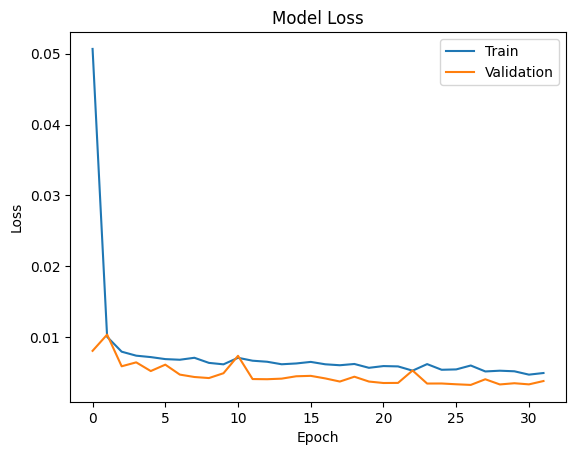

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

In [ ]:
predictions = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step


In [ ]:
predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y_test)

In [ ]:
rmse = np.sqrt(
    mean_squared_error(actual,predictions)
)

print("RMSE:", rmse)

RMSE: 2.1277373628747025


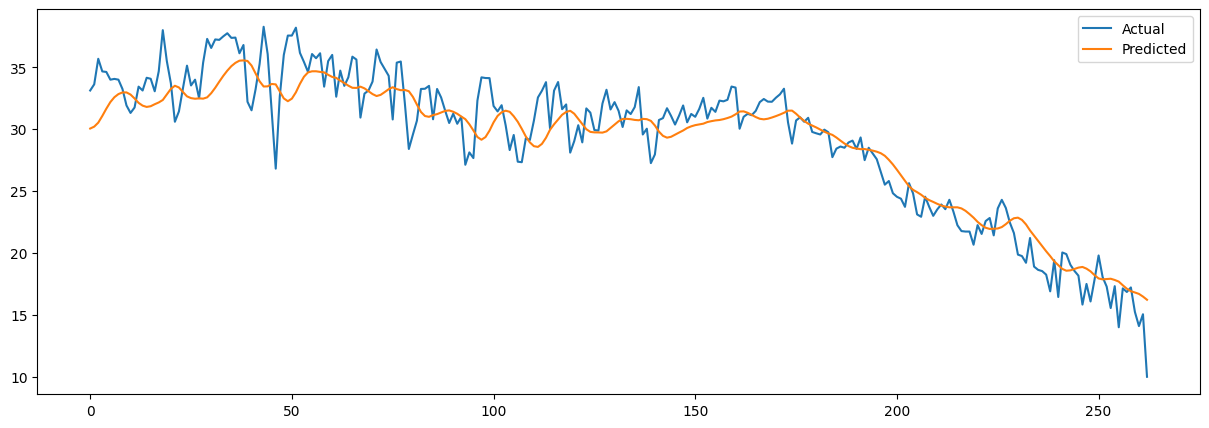

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(actual,label='Actual')
plt.plot(predictions,label='Predicted')

plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

mae = mean_absolute_error(actual,predictions)

r2 = r2_score(actual,predictions)

print("RMSE:",rmse)
print("MAE:",mae)
print("R²:",r2)

RMSE: 2.1277373628747025
MAE: 1.675250325976477
R²: 0.8697428068784204
